In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("students_data.csv")
print(df.head())

   Age  Social_Media_Hours  Study_Hours  Sleep_Hours  Attendance  CGPA
0   18                   6            2            6          70   2.4
1   19                   5            3            6          75   2.7
2   20                   4            4            7          80   3.0
3   21                   3            5            7          85   3.3
4   22                   2            6            8          90   3.7


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 50 non-null     int64  
 1   Social_Media_Hours  50 non-null     int64  
 2   Study_Hours         50 non-null     int64  
 3   Sleep_Hours         50 non-null     int64  
 4   Attendance          50 non-null     int64  
 5   CGPA                50 non-null     float64
dtypes: float64(1), int64(5)
memory usage: 2.5 KB
None


In [7]:
print(df.describe())

             Age  Social_Media_Hours  Study_Hours  Sleep_Hours  Attendance  \
count  50.000000           50.000000    50.000000    50.000000   50.000000   
mean   20.000000            4.700000     3.700000     6.620000   78.360000   
std     1.428571            1.809837     1.631951     1.027976    9.075106   
min    18.000000            1.000000     1.000000     5.000000   60.000000   
25%    19.000000            3.250000     2.250000     6.000000   72.250000   
50%    20.000000            5.000000     4.000000     7.000000   78.500000   
75%    21.000000            6.000000     5.000000     7.000000   85.000000   
max    22.000000            8.000000     7.000000     8.000000   96.000000   

            CGPA  
count  50.000000  
mean    2.931000  
std     0.563597  
min     1.900000  
25%     2.525000  
50%     2.925000  
75%     3.387500  
max     4.000000  


In [8]:
print(df.isnull().sum())

Age                   0
Social_Media_Hours    0
Study_Hours           0
Sleep_Hours           0
Attendance            0
CGPA                  0
dtype: int64


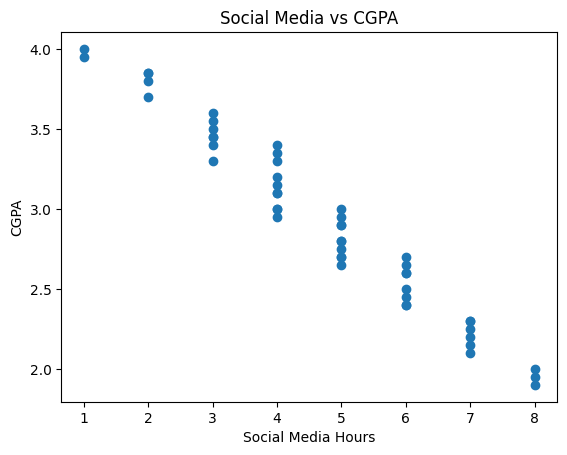

In [9]:
plt.scatter(df["Social_Media_Hours"],df["CGPA"])
plt.xlabel("Social Media Hours")
plt.ylabel("CGPA")
plt.title("Social Media vs CGPA")
plt.show()

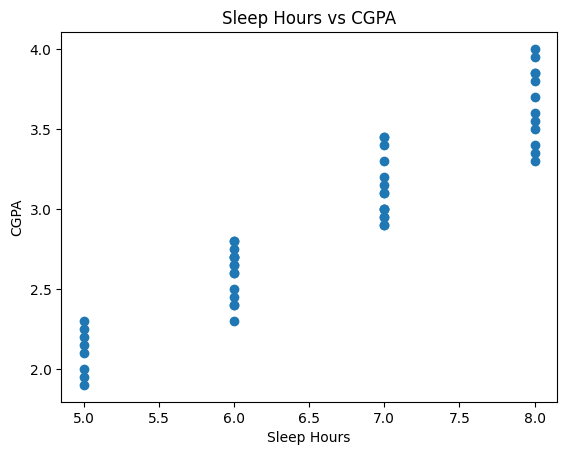

In [10]:
plt.scatter(df["Sleep_Hours"],df["CGPA"])
plt.xlabel("Sleep Hours")
plt.ylabel("CGPA")
plt.title("Sleep Hours vs CGPA")
plt.show()

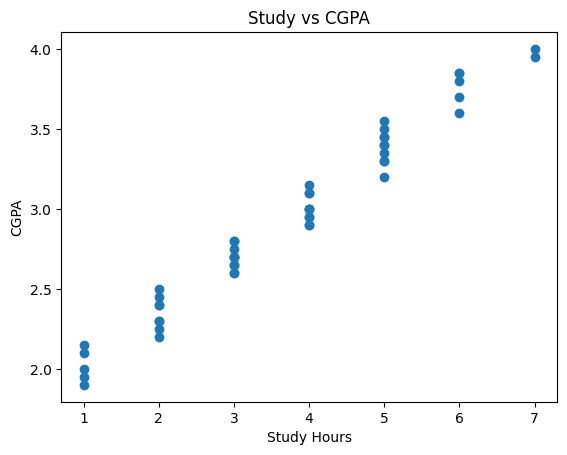

In [11]:
plt.scatter(df["Study_Hours"],df["CGPA"])
plt.xlabel("Study Hours")
plt.ylabel("CGPA")
plt.title("Study vs CGPA")
plt.show()

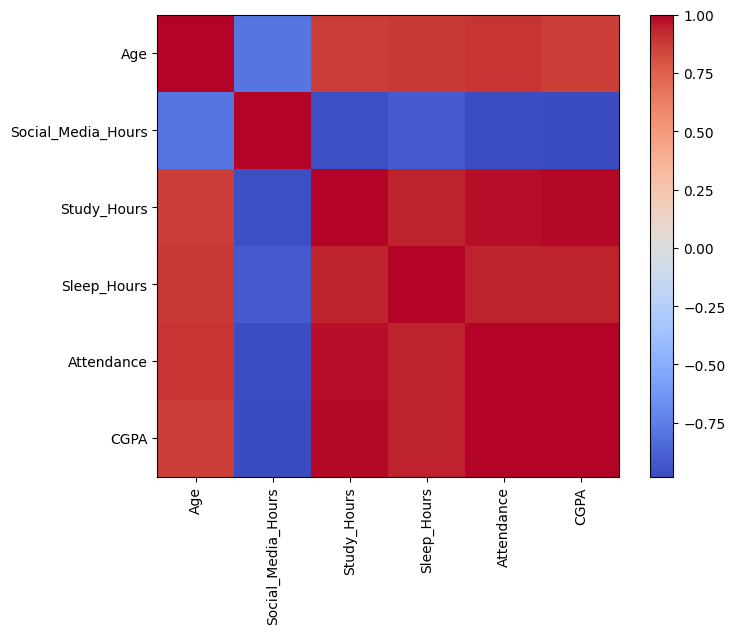

In [13]:
corr=df.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr,cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.show()

In [14]:
#For machine learning:- Scikit learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
X = df[
    [
        "Age",
        "Social_Media_Hours",
        "Study_Hours",
        "Sleep_Hours",
        "Attendance"
    ]
]
y=df["CGPA"]

In [16]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred=model.predict(X_test)
print(y_pred)

[2.99148881 3.49049983 2.45255257 2.67176273 3.33883872 3.72796565
 2.32441283 1.93528589 3.11962856 4.00591471]


In [19]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("Mean Square Error:",mse)
print("r2 score:", r2)


Mean Square Error: 0.003931932584592138
r2 score: 0.9902196814014249


In [20]:
new_student=np.array([[20,5,2,9,70]])
predicted_CGPA=model.predict(new_student)
print("Predicted CGPA:", round(predicted_CGPA[0],2))

Predicted CGPA: 2.63


C:\Users\sidra\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
